```{contents}
:local:
:depth: 2
```

# Classification Basics

Classification is the task of building a model that maps continuous or discrete inputs to a **discrete output** — a class label. Unlike regression, where the goal is to predict a continuous value, classification models must assign each input to one of a finite set of categories. This chapter introduces the core concepts: what makes a good classification dataset, how model accuracy is measured, and how to derive a principled loss function for a linear classifier.

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:

- Describe the classification problem and distinguish it from regression
- Identify properties of a classification dataset: separability, class balance, and number of classes
- Contrast discriminative and generative classification models
- Define and compute accuracy, precision, recall, F1 score, and interpret ROC curves
- Explain strategies for handling class imbalance
- Derive the max-cost (perceptron) loss function from first principles
- Implement and minimize a linear discriminant classifier using Python
:::

## Problem Statement and Datasets

A **classification model** maps inputs $\vec{x}$ to a discrete output $y \in \{0, 1, 2, \ldots\}$. In this course we focus primarily on problems with continuous inputs. We begin by exploring several "toy" datasets that together illustrate the key challenges of classification.

### Toy Datasets

Scikit-learn provides several synthetic datasets that are useful for exploring classification algorithms. We will use four of them throughout this module:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117', '#1879DB', '#8E8B76', '#F5D580', '#002233'])

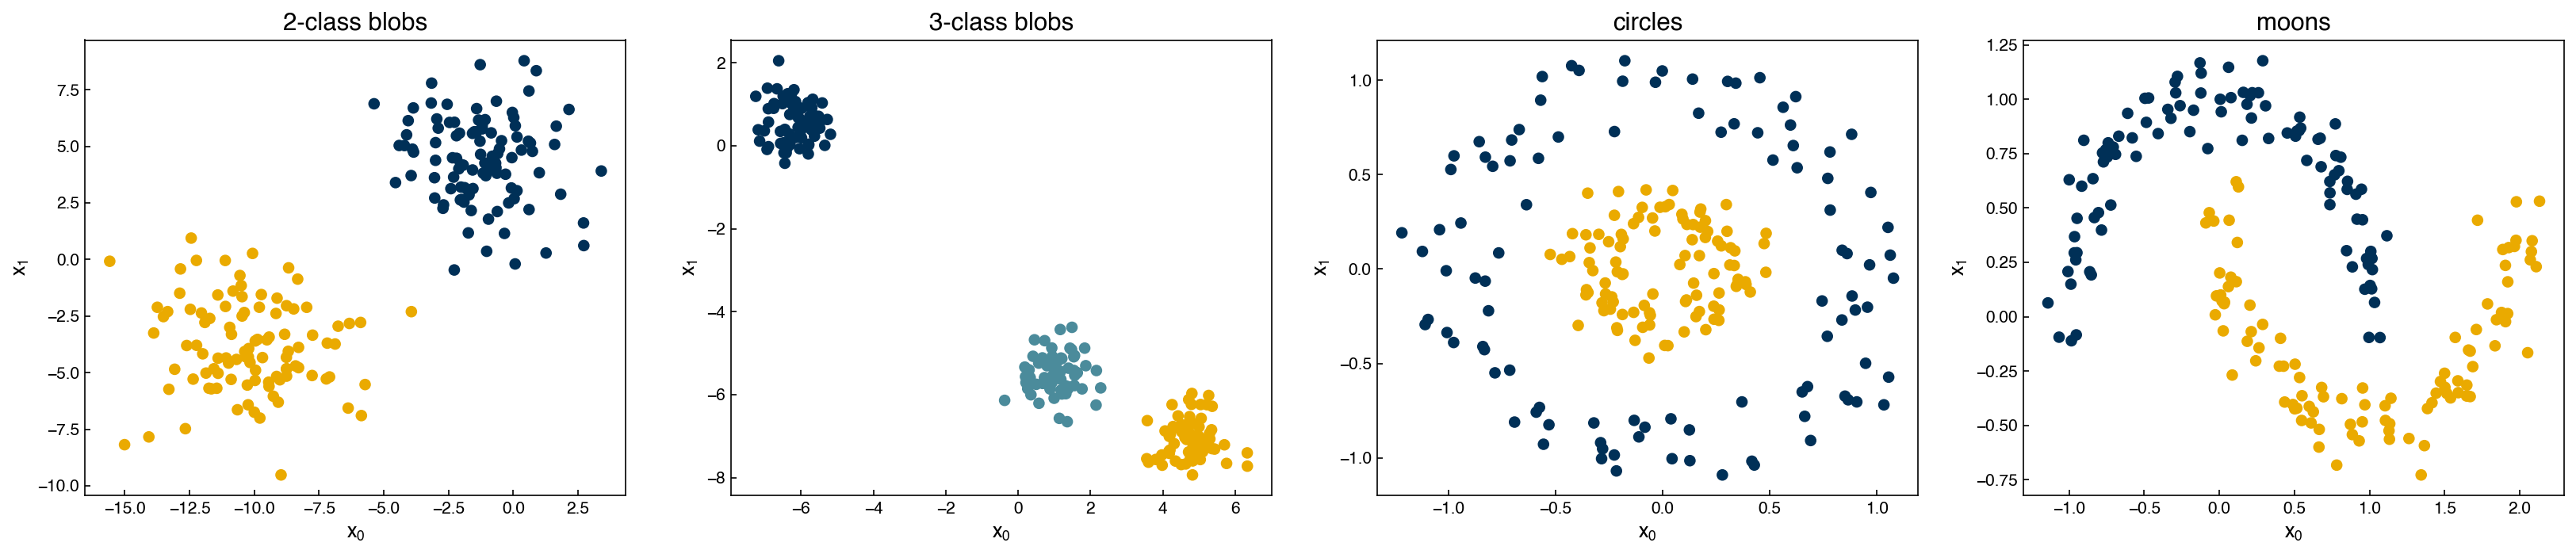

In [2]:
from sklearn.datasets import make_blobs, make_moons, make_circles

np.random.seed(1)  # fix random state for reproducibility
noisiness = 1

X_blob, y_blob = make_blobs(n_samples=200, centers=2, cluster_std=2*noisiness, n_features=2)
X_mc, y_mc = make_blobs(n_samples=200, centers=3, cluster_std=0.5*noisiness, n_features=2)
X_circles, y_circles = make_circles(n_samples=200, factor=0.3, noise=0.1*noisiness)
X_moons, y_moons = make_moons(n_samples=200, noise=0.1*noisiness)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
all_datasets = [[X_blob, y_blob], [X_mc, y_mc], [X_circles, y_circles], [X_moons, y_moons]]
titles = ['2-class blobs', '3-class blobs', 'circles', 'moons']

for i, (Xi, yi) in enumerate(all_datasets):
    axes[i].scatter(Xi[:, 0], Xi[:, 1], c=clrs[yi])
    axes[i].set_xlabel('$x_0$')
    axes[i].set_ylabel('$x_1$')
    axes[i].set_title(titles[i])

plt.show()

A few things to note:

- The random seed is fixed so results are reproducible.
- The `noisiness` variable controls how much overlap exists between classes.
- The outputs $y$ are approximately evenly divided between classes.

:::{exercise}
:label: ex-cls-toy-noisiness

Explore how `noisiness` affects the toy datasets. Set `noisiness` to `0.1`, `1`, and `3` and regenerate the four scatter plots. For which value does the 2-class blobs dataset become approximately linearly separable? At what value do the moons dataset classes begin to overlap significantly?
:::

### Types of Classification Datasets

There are three key properties to consider when examining a classification dataset.

**Linearly separable vs. non-linearly separable vs. inseparable:** A problem is *linearly separable* if the classes can be exactly divided by a straight line (or hyperplane). If separation is only possible with a curved boundary, it is *non-linearly separable*. If no boundary cleanly separates the classes, it is *inseparable*.

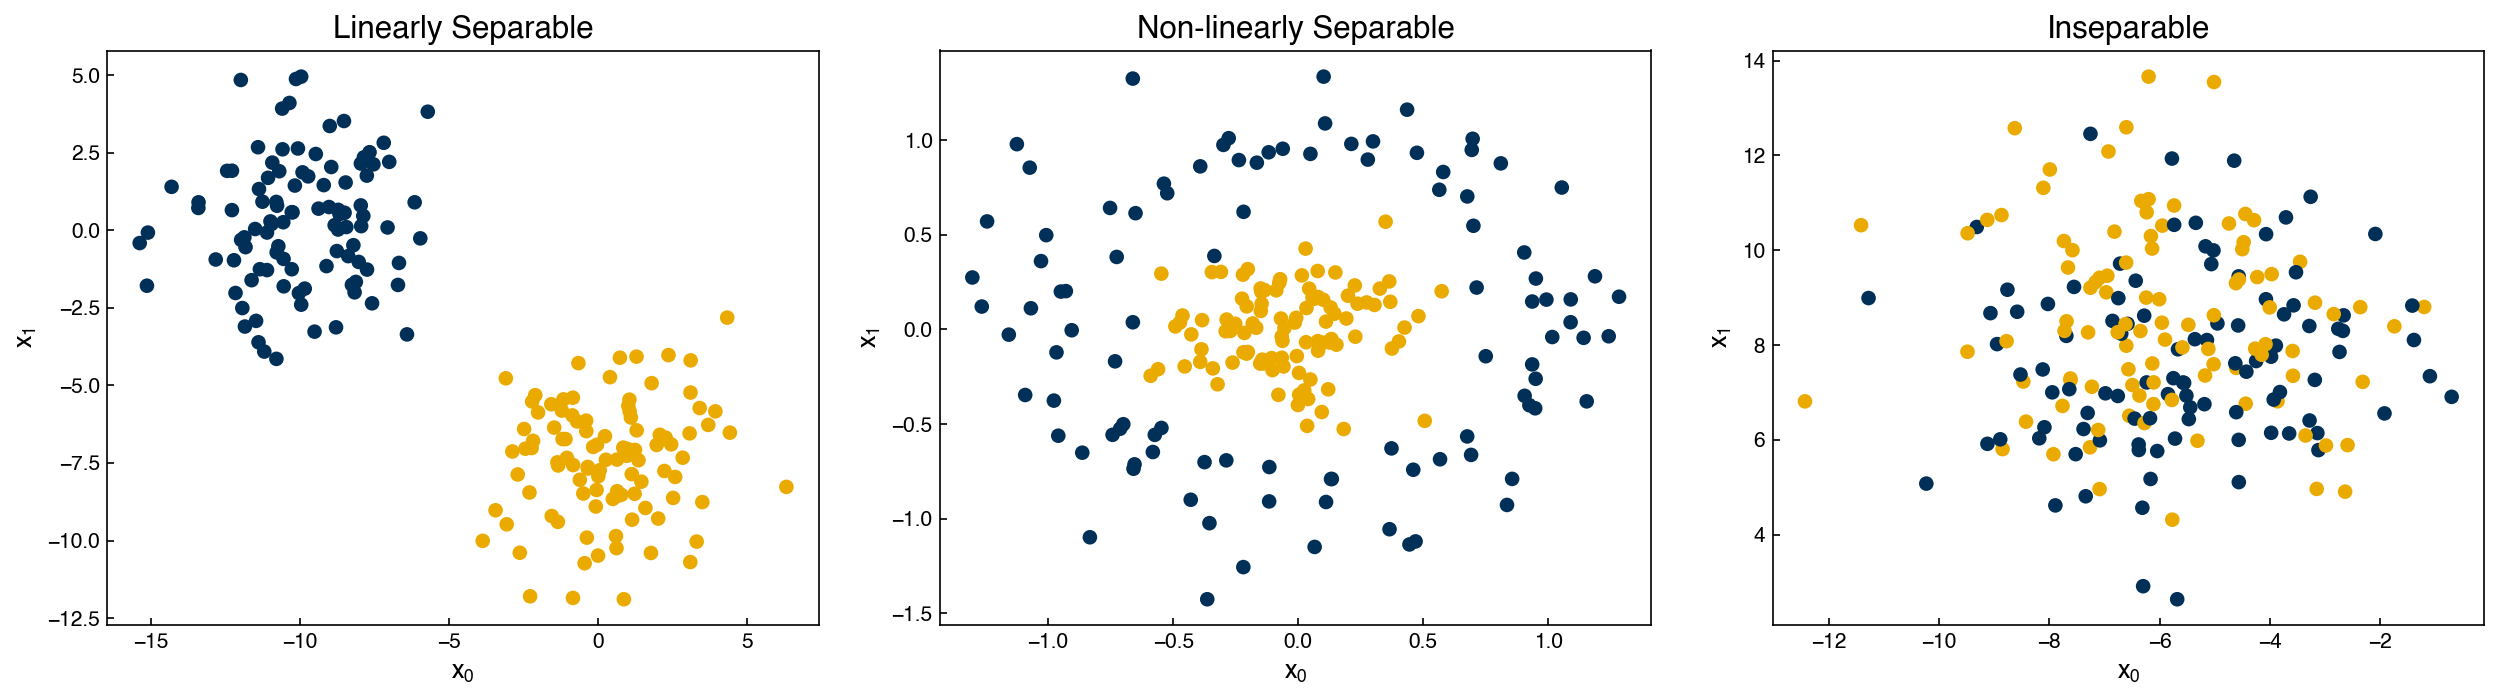

In [3]:
np.random.seed(9)
X_lin, y_lin = make_blobs(n_samples=200, centers=2, cluster_std=2*noisiness, n_features=2)

np.random.seed(5)
X_insep, y_insep = make_blobs(n_samples=200, centers=2, cluster_std=2*noisiness, n_features=2)

X_nonlin, y_nonlin = make_circles(n_samples=200, factor=0.2, noise=0.2*noisiness)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (Xi, yi), title in zip(axes,
        [(X_lin, y_lin), (X_nonlin, y_nonlin), (X_insep, y_insep)],
        ['Linearly Separable', 'Non-linearly Separable', 'Inseparable']):
    ax.scatter(Xi[:, 0], Xi[:, 1], c=clrs[yi])
    ax.set_xlabel('$x_0$')
    ax.set_ylabel('$x_1$')
    ax.set_title(title)

plt.show()

**Binary vs. multi-class:** A binary classification problem has exactly 2 classes; a multi-class problem has 3 or more. Multi-class problems can be handled in two ways:

1. **One-vs-rest (OvR):** decompose into a series of binary classifiers, each distinguishing one class from all others.

:::{figure} images/OvA.png
:name: fig-cls-ova
:width: 90%

**One-vs-rest (OvR) strategy.** Each of the three binary sub-problems is solved independently (panels 1–3): the target class is shown in color and all others are collapsed to grey, with a logistic-regression boundary for that sub-problem. The rightmost panel shows the combined OvR decision regions, with dashed lines indicating where each binary boundary lies.
:::

2. **Native multi-class objective:** modify the loss function or algorithm to handle all classes simultaneously (e.g., k-NN, multi-class logistic regression).

:::{figure} images/multiclass_cost.png
:name: fig-cls-mc-cost
:width: 90%

**Native multi-class objective (softmax regression).** All three class boundaries are learned simultaneously in a single optimization. Left: the raw training data. Center: the three pairwise boundaries meeting at a single point — a hallmark of jointly-trained linear classifiers. Right: the resulting decision regions.
:::

The practical differences between these approaches are often small, though OvR is more amenable to parallel training and multi-class objectives are more efficient in serial.

**Balanced vs. imbalanced:** A balanced dataset has roughly equal class counts; an imbalanced dataset has many more examples of some classes than others. Class imbalance can significantly distort accuracy metrics and requires special handling during model training and evaluation.

### Discriminative vs. Generative Models

There are two fundamentally different philosophies for building a classification model.

**Discriminative models** directly estimate the probability of a class label given the input features:

$$P(y_i | \vec{x}) = f(\vec{x})$$

The goal is to find a decision boundary that separates the classes. This is conceptually similar to regression — instead of fitting a curve through data, we fit a boundary *between* groups. We will focus primarily on discriminative models in this module.

**Generative models** instead estimate the probability of observing the features *given* a class label:

$$P(\vec{x} | y_i) = f(\vec{x})$$

This is the "inverse" problem. Bayes' rule then recovers the class probabilities:

$$P(y_i | \vec{x}) = \frac{P(\vec{x} | y_i)\, P(y_i)}{P(\vec{x})}$$

where $P(y_i)$ is estimated from class frequencies in the data and $P(\vec{x})$ is a normalizing constant. Generative models are harder to train but have a key advantage: they can *generate* new synthetic data samples — the basis of Generative Adversarial Networks (GANs) and similar methods.

:::{figure} images/discriminative_vs_generative.png
:name: fig-cls-disc-gen
:width: 90%

**Discriminative vs. generative models.** Left: a discriminative model learns a decision boundary directly; a test point (red star) is classified by which side of the boundary it falls on. Right: a generative model fits class-conditional distributions $P(\mathbf{x}\,|\,y)$ (shown as 1-σ and 2-σ confidence ellipses); the test point — outside both ellipses — has low probability under either class, something a discriminative model cannot detect.
:::

## Accuracy Metrics and Model Validation

Evaluating the quality of a classification model requires different metrics than regression because the output is discrete. A single number like mean squared error is no longer meaningful.

### False Positives and False Negatives

For any binary classifier, errors fall into exactly two categories:

- **False positive (Type I error):** the model predicts class 1, but the true label is 0.
- **False negative (Type II error):** the model predicts class 0, but the true label is 1.

The assignment of 0 and 1 is arbitrary, so these error types can be swapped — but they represent qualitatively different failures with different real-world consequences.

:::{note}
**Chemical engineering context — reactor runaway detection:** Suppose a model predicts whether a reactor is approaching runaway conditions. A **false positive** (predicting runaway when conditions are safe) triggers an unnecessary shutdown, causing downtime and economic loss. A **false negative** (missing an actual runaway) could lead to a hazardous and potentially catastrophic situation. In safety-critical applications like this, **false negatives are typically far more costly** than false positives, and the model should be tuned to minimize them even at the expense of more false alarms. This is why understanding the difference between error types — not just overall accuracy — is essential.
:::

### Accuracy, Precision, Recall, and F1 Score

Four standard metrics summarize classifier performance for binary problems:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1} = \frac{2 \cdot \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The F1 score is the harmonic mean of precision and recall. It ranges from 0 (worst) to 1 (perfect) and is particularly useful when classes are imbalanced because it penalizes models that sacrifice either precision or recall.

:::{figure} images/precision_recall.png
:name: fig-cls-prec-rec
:width: 80%

**Precision and recall.** The left band contains all actual positives; the right band contains all actual negatives. The dashed ellipse marks the set of predicted positives. Dots are colored by outcome: navy (TP), gold (FN), red (FP), grey (TN). Precision measures how many predicted positives are correct; recall measures how many actual positives are found.
:::

In [4]:
def acc_prec_recall(y_model, y_actual):
    TP = np.sum(np.logical_and(y_model == y_actual, y_model == 1))
    TN = np.sum(np.logical_and(y_model == y_actual, y_model == 0))
    FP = np.sum(np.logical_and(y_model != y_actual, y_model == 1))
    FN = np.sum(np.logical_and(y_model != y_actual, y_model == 0))
    acc = (TP + TN) / (TP + TN + FP + FN)
    if TP == 0:
        prec, recall = 0, 0
    else:
        prec = TP / (TP + FP)
        recall = TP / (TP + FN)
    return acc, prec, recall

These metrics depend critically on class balance. To see why, consider a "trivial" classifier that always predicts class 0. Even this model can achieve misleadingly high accuracy on an imbalanced dataset:

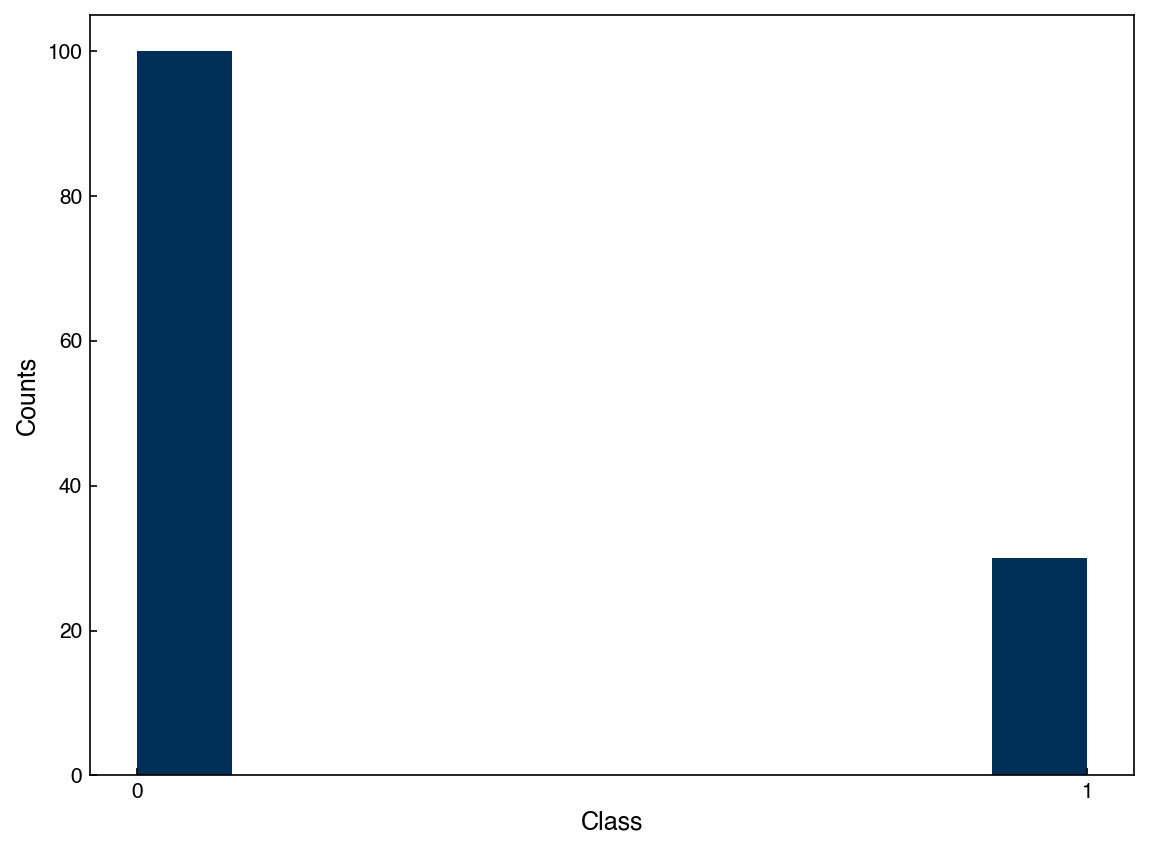

In [5]:
# Build an imbalanced dataset: keep only 30 examples of class 1
N_include = 30
y_imbalanced = []
Ni = 0
for yi in y_moons:
    if yi == 1 and Ni < N_include:
        y_imbalanced.append(yi)
        Ni += 1
    elif yi == 0:
        y_imbalanced.append(yi)

y_imbalanced = np.array(y_imbalanced)

fig, ax = plt.subplots()
ax.hist(y_imbalanced)
ax.set_xticks([0, 1])
ax.set_xlabel('Class')
ax.set_ylabel('Counts')
plt.show()

In [6]:
# Trivial classifier: always predict class 0
y_guess = np.zeros(len(y_imbalanced))
acc, prec, recall = acc_prec_recall(y_guess, y_imbalanced)
print(f'Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {recall:.3f}')

Accuracy: 0.769, Precision: 0.000, Recall: 0.000


The accuracy is ~77% even though the model is completely uninformative. Precision and recall both correctly return 0, revealing the model's failure.

**Demonstration — how accuracy degrades with class imbalance:**

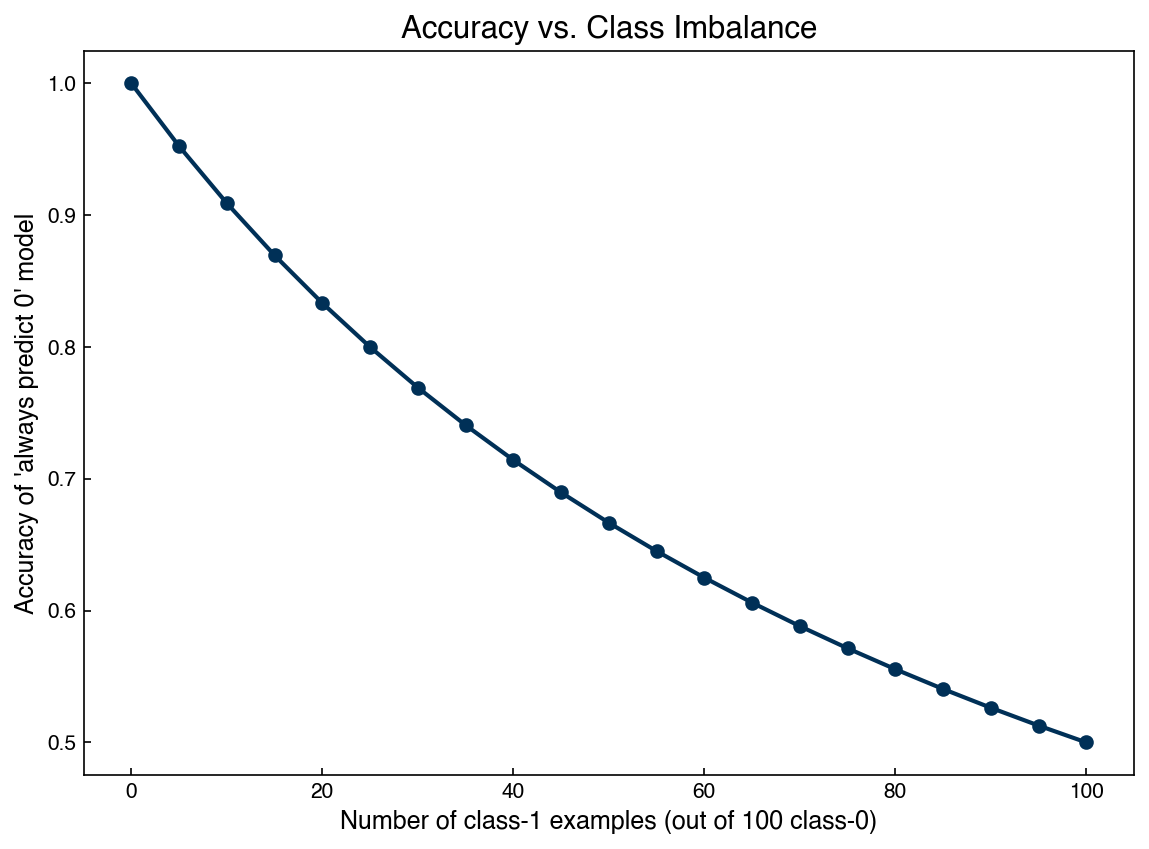

In [7]:
n_ones_range = list(range(0, 101, 5))
accuracies = []

for n_ones in n_ones_range:
    y_test = np.array([0] * 100 + [1] * n_ones)
    y_pred = np.zeros(len(y_test))
    acc_i, _, _ = acc_prec_recall(y_pred, y_test)
    accuracies.append(acc_i)

fig, ax = plt.subplots()
ax.plot(n_ones_range, accuracies, marker='o')
ax.set_xlabel("Number of class-1 examples (out of 100 class-0)")
ax.set_ylabel("Accuracy of 'always predict 0' model")
ax.set_title("Accuracy vs. Class Imbalance")
plt.show()

As the proportion of class-1 examples decreases, the trivial "always guess 0" model achieves higher and higher accuracy — approaching 100% as class 1 becomes vanishingly rare. This is why accuracy alone is an unreliable metric for imbalanced problems.

:::{exercise}
:label: ex-cls-f1-compute

Using the `acc_prec_recall` function above, compute the accuracy, precision, recall, and F1 score for a classifier on the `y_moons` dataset. First, train a `RandomForestClassifier` from `sklearn.ensemble` on the full (balanced) `X_moons`, `y_moons` data and evaluate its metrics. Then repeat on the imbalanced version `y_imbalanced` (using the corresponding subset of `X_moons`). Compare the F1 scores and explain the difference.
:::

### Receiver Operating Characteristic (ROC) Curves

Many classifiers produce a continuous-valued score before applying a threshold to produce a binary prediction. The **ROC curve** shows how the true positive rate (recall) and false positive rate trade off as that threshold is varied.

:::{figure} images/ROC_curve.png
:name: fig-cls-roc
:width: 60%

ROC curves for three model quality levels. A worthless classifier (AUC = 0.50) traces the diagonal — it performs no better than random guessing. A good classifier (AUC ≈ 0.86) bows toward the upper-left corner, and an excellent classifier (AUC ≈ 0.97) hugs it tightly. The shaded area illustrates what AUC measures.
:::

A model that performs no better than random chance traces the diagonal; a perfect model reaches the upper-left corner. The **area under the ROC curve (AUC)** is a single-number summary: higher is better.

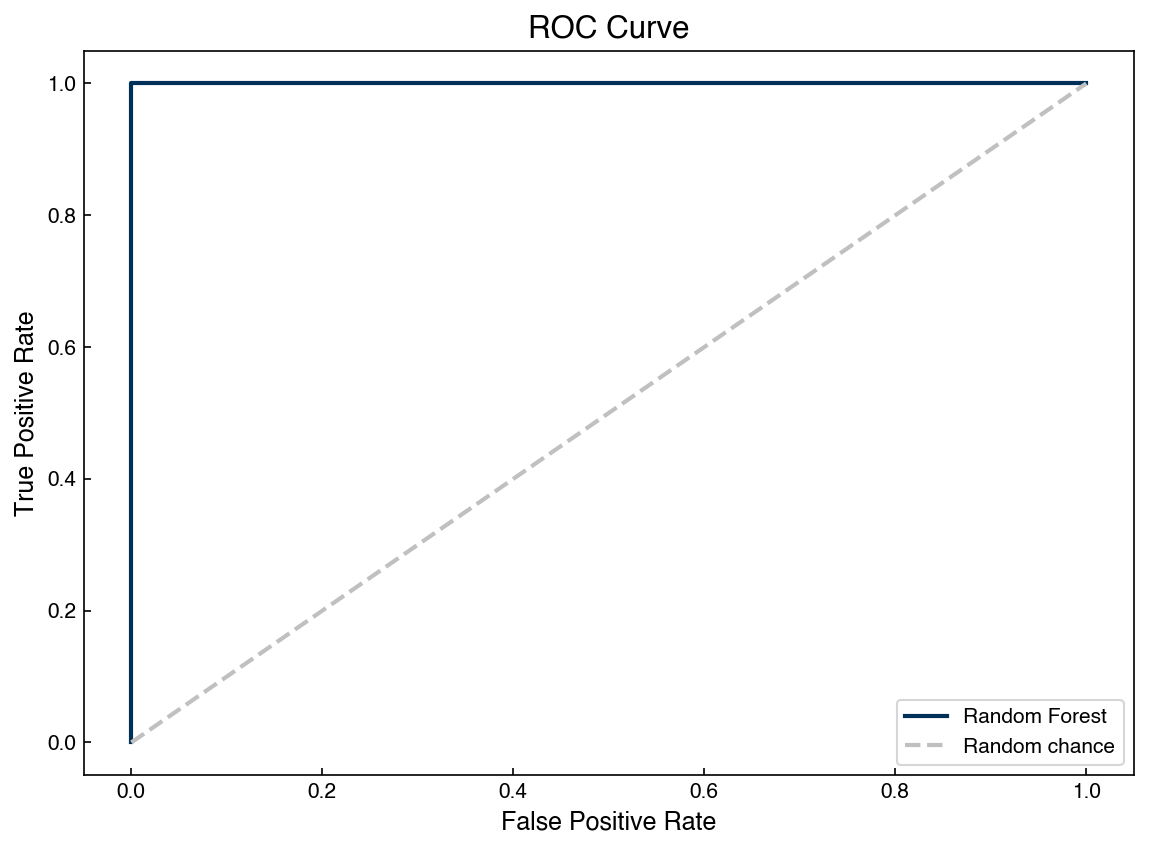

In [8]:
from sklearn.metrics import roc_curve
from sklearn.ensemble import RandomForestClassifier

np.random.seed(5)
X_blob2, y_blob2 = make_blobs(n_samples=200, centers=2, cluster_std=2*noisiness, n_features=2)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_blob2, y_blob2)

fpr, tpr, _ = roc_curve(y_blob2, rf.predict_proba(X_blob2)[:, 1])

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label='Random Forest')
ax.plot([0, 1], [0, 1], '#C0C0C0', linestyle='--', label='Random chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

:::{note}
The ROC curve evaluates performance across all possible thresholds. It is most informative when you have a probabilistic classifier and want to understand the precision/recall tradeoff before choosing an operating point.
:::

### Confusion Matrices

The confusion matrix generalizes false positives and false negatives to **multi-class** problems. Each row corresponds to a true class and each column to a predicted class. Diagonal entries are correct predictions; off-diagonal entries are errors.

:::{figure} images/confusion_matrix_iris.png
:name: fig-cls-confmat
:width: 60%

A confusion matrix for a multi-class classifier (the iris flower dataset, classified using only its two sepal features). Diagonal elements are true positives/negatives; off-diagonal elements reveal which classes are being confused with each other.
:::

Confusion matrices are especially useful for diagnosing *which* classes are problematic. For example, if class A is frequently misclassified as class B but rarely confused with class C, the confusion matrix reveals this structure immediately.

### Cross-Validation and Resampling

Cross-validation for classification follows the same general principle as regression: withhold some data during training and evaluate on the held-out set. However, class imbalance introduces an additional complication — a naive random split may place very few minority-class examples in the test fold, making evaluation noisy or misleading.

The solution is **stratified** splitting: ensure each fold preserves the original class proportions. Scikit-learn's `StratifiedKFold` does this automatically.

When the imbalance is severe, simply stratifying the split may not be enough. Four common strategies address the imbalance itself:

1. **Re-balance the cost function:** weight minority-class errors more heavily in the loss. Many scikit-learn estimators accept a `class_weight='balanced'` argument.

2. **Undersampling:** discard examples from the over-represented class. Simple but wastes data.

:::{figure} images/undersampling.png
:name: fig-cls-undersamp
:width: 80%

**Undersampling.** Left: with a 15:1 class imbalance, LDA's empirical-prior boundary (red) is pulled almost onto the minority cluster, misclassifying roughly half of minority examples. The dashed line shows the theoretical ideal at the class midpoint. Right: after randomly discarding 140 majority examples the boundary moves close to the ideal — but 140 real data points (grey) are thrown away.
:::

3. **Oversampling:** repeat minority-class examples. Can lead to overfitting because the decision boundary is optimized on duplicates.

:::{figure} images/oversampling.png
:name: fig-cls-oversamp
:width: 80%

**Oversampling.** After duplicating the 10 minority examples 15× to restore balance, an RBF-kernel SVM learns a non-linear boundary that wraps tightly around the repeated training positions — including an isolated "island" around a single outlier point in majority territory. This is a hallmark of overfitting to duplicated samples.
:::

4. **SMOTE (Synthetic Minority Oversampling Technique):** generate *new* synthetic minority-class examples by interpolating between existing ones. More robust than naive oversampling because it introduces controlled variation.

:::{figure} images/smote.png
:name: fig-cls-smote
:width: 80%

**SMOTE.** Synthetic minority examples (hollow circles) are created by interpolating between existing minority points. The RBF-SVM boundary is now smooth and contiguous — no isolated islands — and sits closer to the theoretical ideal than the naive oversampling boundary.
:::

:::{exercise}
:label: ex-cls-stratified-cv

Implement 5-fold cross-validation on the imbalanced moons dataset constructed earlier. Use `StratifiedKFold` from `sklearn.model_selection` with a `RandomForestClassifier`. For each fold, compute and print the accuracy and F1 score. Compare the mean F1 score across folds to the F1 score obtained when training and testing on the full imbalanced dataset without cross-validation. What does this comparison reveal about overfitting?
:::

## Multi-Class Classification

When there are more than two classes the problem is called **multi-class** classification. The fundamental ideas are the same — we want a model that maps inputs to one of $K$ discrete labels — but both the model structure and the evaluation metrics become slightly more involved.

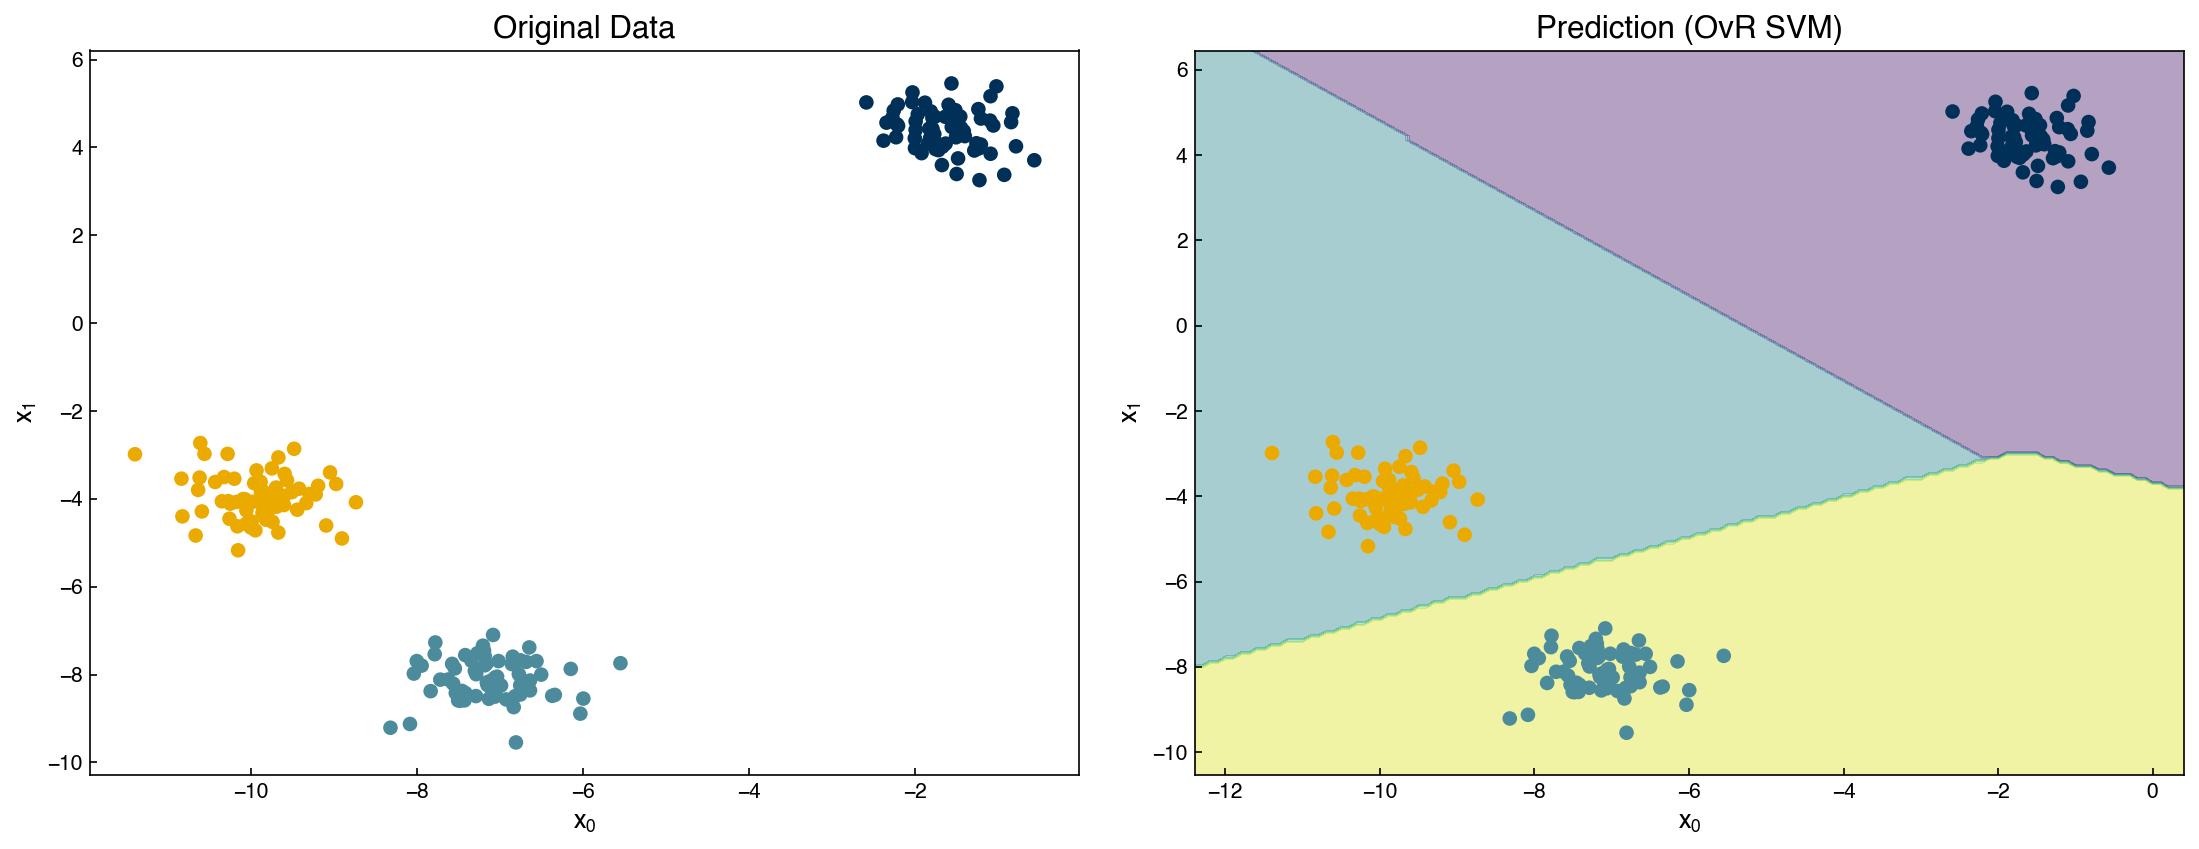

In [9]:
from sklearn.svm import SVC

np.random.seed(1)
X_mc3, y_mc3 = make_blobs(n_samples=200, centers=3, cluster_std=0.5*noisiness, n_features=2)

# Train a linear SVM with one-vs-rest multi-class strategy
model = SVC(kernel='linear', C=1, decision_function_shape='ovr')
model.fit(X_mc3, y_mc3)
y_mc_hat = model.predict(X_mc3)

# Build a grid to visualize the decision boundaries
x_min, x_max = X_mc3[:, 0].min() - 1, X_mc3[:, 0].max() + 1
y_min, y_max = X_mc3[:, 1].min() - 1, X_mc3[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(X_mc3[:, 0], X_mc3[:, 1], c=clrs[y_mc3])
axes[0].set_title('Original Data')
axes[1].contourf(xx, yy, Z, alpha=0.4)
axes[1].scatter(X_mc3[:, 0], X_mc3[:, 1], c=clrs[y_mc_hat])
axes[1].set_title('Prediction (OvR SVM)')
for ax in axes:
    ax.set_xlabel('$x_0$')
    ax.set_ylabel('$x_1$')
plt.show()

The SVM above uses the one-vs-rest strategy: three binary classifiers are trained, and the class with the highest decision function value is selected. The shaded regions show the three decision regions learned by the model.

:::{exercise}
:label: ex-cls-multiclass-metrics

Evaluate the multi-class SVM trained above using a confusion matrix. Import `confusion_matrix` from `sklearn.metrics`, compute it from `y_mc3` (true labels) and `y_mc_hat` (predicted labels), and display it. Which pair of classes, if any, has the most confusion? Explain why based on the scatter plot.
:::

## Deriving a Loss Function for Discrimination

So far we have used classifiers from scikit-learn without examining how they work internally. Let us now derive a loss function for a **linear discriminant** — the simplest discriminative classifier — from first principles.

### Linear Discriminant Setup

Consider a binary classification problem with labels $y_i \in \{+1, -1\}$ and a linear model $f(\vec{x}) = \bar{\bar{X}}\vec{w}$, where $\bar{\bar{X}} = [\vec{1},\, \vec{x}]$ augments the inputs with a bias column (exactly as in linear regression). The classification rule is:

$$\bar{\bar{X}}\vec{w} > 0 \quad \text{if } y_i = +1$$
$$\bar{\bar{X}}\vec{w} < 0 \quad \text{if } y_i = -1$$

**Demonstration — the decision boundary:**

For a model with inputs $x_0$ and $x_1$ and weights $\vec{w} = [w_0,\, w_1,\, w_2]$ (bias, $x_0$ weight, $x_1$ weight), the decision boundary is the set of points where:

$$w_0 + x_0 w_1 + x_1 w_2 = 0 \quad \Longrightarrow \quad x_1 = -\frac{w_1}{w_2}\, x_0 - \frac{w_0}{w_2}$$

So the slope of the decision line is $m = -w_1/w_2$ and the intercept is $b = -w_0/w_2$.

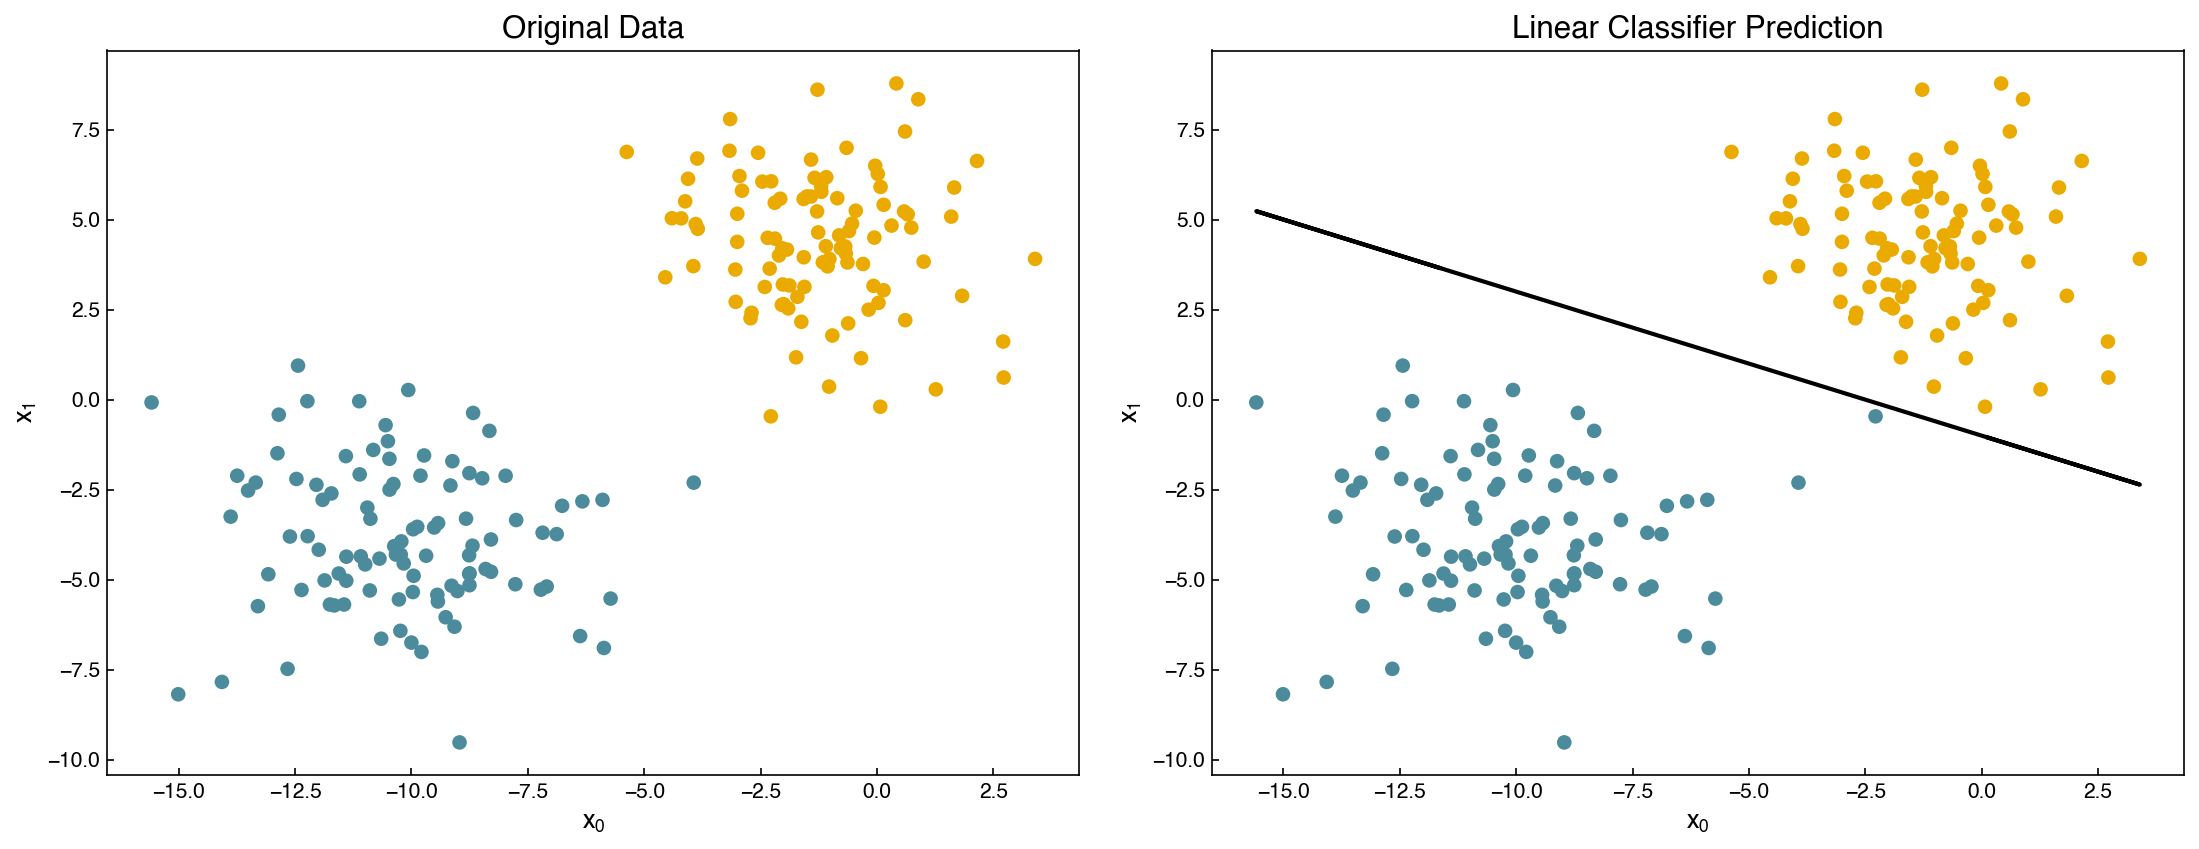

In [10]:
def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def linear_classifier(X, w):
    return np.dot(add_intercept(X), w) > 0

X = X_blob
y = y_blob * 2 - 1  # convert labels from {0,1} to {-1,+1}

w = np.array([-10, -4, -10])
prediction = linear_classifier(X, w)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(X[:, 0], X[:, 1], c=clrs[y_blob + 1])
axes[0].set_title('Original Data')

axes[1].scatter(X[:, 0], X[:, 1], c=clrs[prediction.astype(int) + 1])
m = -w[1] / w[2]
b = -w[0] / w[2]
axes[1].plot(X[:, 0], m * X[:, 0] + b, ls='-', color='black')
axes[1].set_title('Linear Classifier Prediction')

for ax in axes:
    ax.set_xlabel('$x_0$')
    ax.set_ylabel('$x_1$')
plt.show()

### The Max-Cost (Perceptron) Loss Function

To *learn* the weights $\vec{w}$ from data, we need an objective function to minimize. Multiplying both sides of the classification rule by $y_i$ collapses the two conditions into one:

$$-y_i\, \bar{\bar{X}}\vec{w} < 0 \quad \text{for a correctly classified point}$$

Taking the maximum with zero converts this into a non-negative quantity that equals zero for correct predictions and is positive for errors:

$$\max\!\left(0,\; -y_i\, \bar{\bar{X}}\vec{w}\right) = 0 \quad \text{if correct}$$

Summing over all data points gives the **max-cost loss** (also called the perceptron loss):

$$g(\vec{w}) = \sum_i \max\!\left(0,\; -y_i\, \bar{\bar{X}}\vec{w}\right)$$

Minimizing $g$ with respect to $\vec{w}$ finds the weights that best separate the classes.

In [11]:
def max_cost(w, X, y):
    Xb = np.dot(add_intercept(X), w)
    return np.sum(np.maximum(0, -y * Xb))

print(f'Max cost at initial w: {max_cost(w, X, y):.4f}')

Max cost at initial w: 3.7510


### Counting Loss Function

An alternative is to simply count the number of misclassified points:

In [12]:
def n_wrong(w, X=X_blob, y=y):
    Xb = np.dot(add_intercept(X), w)
    return np.sum(np.maximum(0, np.sign(-y * Xb)))

print(f'Number wrong at initial w: {n_wrong(w):.0f}')

Number wrong at initial w: 1


We can minimize either loss using `scipy.optimize.minimize`:

Number wrong after optimization: 1


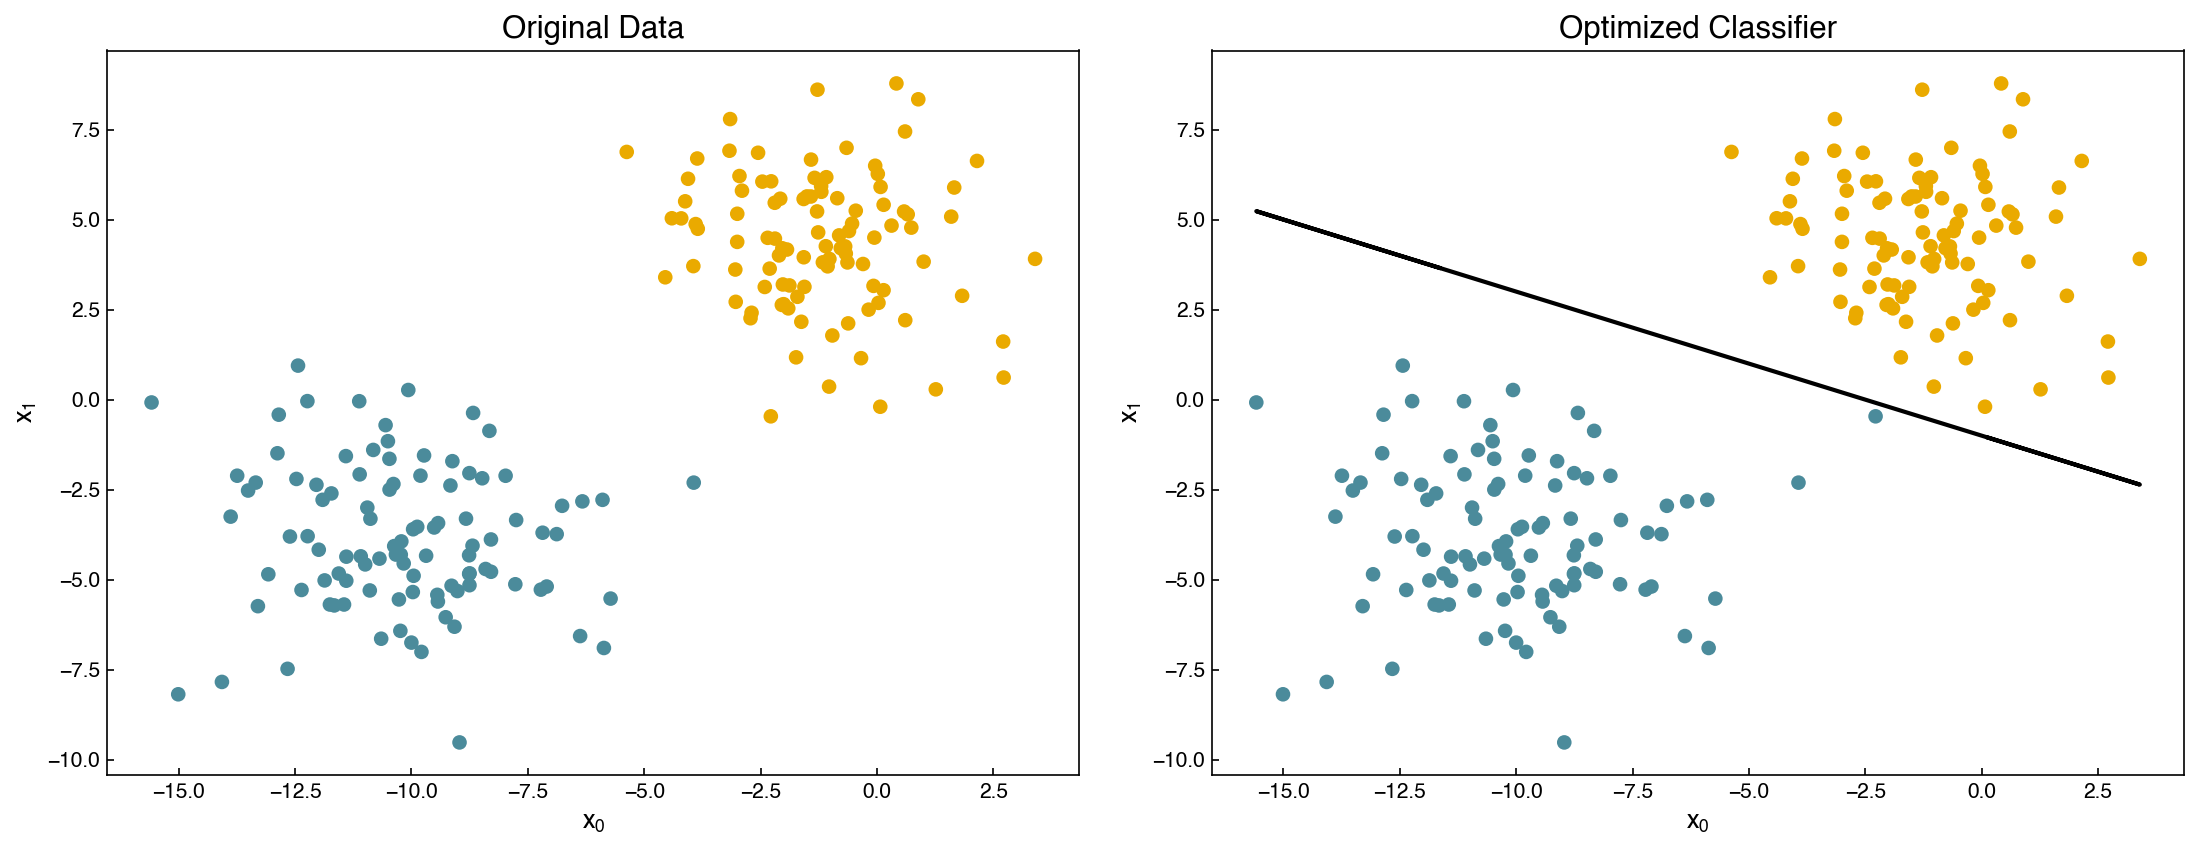

In [13]:
from scipy.optimize import minimize

result = minimize(n_wrong, w)
w_count = result.x
print(f'Number wrong after optimization: {n_wrong(w_count):.0f}')

prediction_opt = linear_classifier(X, w_count)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(X[:, 0], X[:, 1], c=clrs[y_blob + 1])
axes[0].set_title('Original Data')

axes[1].scatter(X[:, 0], X[:, 1], c=clrs[prediction_opt.astype(int) + 1])
m_opt = -w_count[1] / w_count[2]
b_opt = -w_count[0] / w_count[2]
axes[1].plot(X[:, 0], m_opt * X[:, 0] + b_opt, ls='-', color='black')
axes[1].set_title('Optimized Classifier')

for ax in axes:
    ax.set_xlabel('$x_0$')
    ax.set_ylabel('$x_1$')
plt.show()

:::{note}
The counting loss (number of misclassifications) is *not differentiable* because it uses the `sign` function, which has zero derivative almost everywhere and is undefined at zero. This makes gradient-based optimization unreliable. The max-cost loss is piecewise linear and has well-defined subgradients, making it better behaved. In practice, the max-cost loss tends to produce the same optimal decision boundary but is more amenable to gradient-based optimization algorithms.
:::

:::{exercise}
:label: ex-cls-loss-surface

Compute and plot the max-cost loss $g(\vec{w})$ as a function of the slope parameter $w_1$ for the 2-class blobs dataset, holding $w_0 = -10$ and $w_2 = -10$ fixed. Vary $w_1$ over the range $[-20, 5]$ using `np.linspace`. At what value of $w_1$ is the loss minimized? How does this compare to the value found by `scipy.optimize.minimize`?
:::

## Summary

- A **classification model** maps continuous inputs to discrete class labels. The output space is categorical rather than continuous.
- Toy datasets (blobs, moons, circles) reveal three key dataset properties: **linear separability**, **binary vs. multi-class structure**, and **class balance**.
- **Discriminative models** directly estimate $P(y|\vec{x})$ by learning a decision boundary. **Generative models** estimate $P(\vec{x}|y)$ and recover class probabilities via Bayes' rule.
- **Accuracy** is misleading when classes are imbalanced. **Precision**, **recall**, and the **F1 score** give a more complete picture. **ROC curves** and AUC summarize performance across all possible classification thresholds.
- **Confusion matrices** generalize binary error types to multi-class problems and reveal which classes are being confused.
- Class imbalance can be addressed by re-weighting the cost function, undersampling, oversampling, or synthetic resampling (SMOTE).
- The **max-cost (perceptron) loss** is derived directly from the classification rule and can be minimized to find the optimal linear discriminant weights. The **counting loss** (number of misclassifications) is non-differentiable and less suitable for gradient-based optimization.

## Additional Reading

- [Scikit-learn: Classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics) — Comprehensive reference for accuracy, precision, recall, F1, and ROC curves in scikit-learn
- [Imbalanced-learn documentation](https://imbalanced-learn.org/stable/) — The `imbalanced-learn` library provides SMOTE, ADASYN, and many other resampling strategies
- Hastie, Tibshirani, and Friedman. *The Elements of Statistical Learning*, Chapter 4: "Linear Methods for Classification". [Available online](https://hastie.su.domains/ElemStatLearn/)
- [Understanding the Perceptron Algorithm](https://towardsdatascience.com/perceptron-algorithm-its-variants-and-pseudo-code-4d3e9c2c96c0) — An intuitive walkthrough of the perceptron loss and learning rule